# Arena Sagaz — Treinamento CNN (V7 Adaptativo & HighPerf)

Este notebook processa o revolucionário dataset **V7**, gerado sob o algoritmo **DAC (Diversidade Adaptativa em Cascata)** e *Scorado* com a engine de **Alta Performance (Bitboard 64-bits)**.

### O que mudou em relação às versões antigas (V4/V5/V6):
- **Adeus ao `generation_mode`:** A V7 não usa mais cotas artificiais nem modos de geração separados. A distribuição do dataset é uma curva de sino natural (emergente) extraída de 30 snapshots por partida.
- **Campos de Alta Fidelidade:** Os rótulos de treinamento agora usam `melhor_jogada` e os Q-values usam `score_melhor_jogada`, todos rigorosamente testados e livres de ruído (bugs de offset Alpha-Beta ou caixas pré-fechadas foram dizimados pela engine Bitboard do Databricks).
- **Novas Faixas de Jogo (0-11, 12-17, 18-23, 24-28, 29-31):** A avaliação do modelo agora estratifica e exibe métricas (Top-1, 3 e 5) respeitando as densidades reais de Abertura, 1ª/2ª Metade, Fase Quente e Final.
- **Filtro de Matrizes Duplicadas:** O parâmetro `UTILIZACAO_MATRIZES` garante que a rede treine sem o viés do estrangulamento.
- **Análise de Viés de Borda:** Relatório exclusivo para auditar se a CNN vicia em jogar nas quinas/bordas em comparação com o mestre Minimax.

> **Contrato de Codificação:** A normalização para o treinamento (`8` -> `0`, `9` -> `1`) segue invicta como dita o `contrato_codificacao_pontinhos.json`.


In [21]:
# =========================================================================
# CONFIGURACAO — edite aqui antes de rodar
# =========================================================================
from google.colab import drive
drive.mount('/content/drive')

# Pasta no Drive onde o .tflite será salvo (criada automaticamente)
DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/Arena Sagaz/CNN'

# Pasta local dos NPZ — aponte para onde fez upload dos dados
PASTA_NPZ = '../dados/profundidade_minimax_7_v7_adaptativo'

# Controle de filtragem de dados
# Opções: 'DISTINTAS' (apenas matrizes únicas) ou 'INCLUI_DUPLICADAS' (todas)
UTILIZACAO_MATRIZES = 'INCLUI_DUPLICADAS'

import os
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
print(f"Drive montado. Modelos serao salvos em: {DRIVE_OUTPUT_DIR}")
print(f"Lendo NPZ de: {PASTA_NPZ}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado. Modelos serao salvos em: /content/drive/MyDrive/Arena Sagaz/CNN
Lendo NPZ de: ../dados/profundidade_minimax_7_v7_adaptativo


In [22]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reduz logs internos do TensorFlow para deixar a saída do notebook mais limpa.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sns.set_theme(style="whitegrid")

# Sementes fixas para reprodutibilidade dos experimentos.
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.20.0
GPU disponível: True


In [23]:
# =========================================================================
# 1.1 LEITURA DOS LOTES
# =========================================================================
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

MODE_NAMES = {0: 'random(p=0)', 1: 'autoplay(p=1)', 2: 'autoplay(p=2)', 3: 'autoplay(p=3)'}

# Configuracao de pesos por generation_mode (sample_weight).
# Defina USE_SAMPLE_WEIGHT = False para treinar sem pesos (recomendado como baseline).
USE_SAMPLE_WEIGHT = False
MODE_WEIGHTS = {0: 1.0, 1: 2.0, 2: 3.0, 3: 3.0}  # ajuste conforme resultados

arquivos_npz = sorted(glob.glob('../dados_v3/*.npz'))
if not arquivos_npz:
    arquivos_npz = sorted(glob.glob('*.npz'))
print(f'Encontrados {len(arquivos_npz)} arquivos.')

lista_estados, lista_rotulos, lista_scores, lista_gen_modes = [], [], [], []
labels_canonicos = None

for arquivo in arquivos_npz:
    dados = np.load(arquivo, allow_pickle=True)
    lista_estados.append(dados['estados'])
    lista_rotulos.append(dados['melhor_jogada'])
    lista_scores.append(dados['score_melhor_jogada'])
    # Compatibilidade com datasets V2 (sem generation_mode)
    if 'generation_mode' in dados:
        lista_gen_modes.append(dados['generation_mode'])
    else:
        lista_gen_modes.append(np.zeros(len(dados['estados']), dtype=np.int8))
    if labels_canonicos is None:
        labels_canonicos = dados['labels_canonicos'].tolist()

X_raw        = np.concatenate(lista_estados,   axis=0).astype(np.float32)
y_str        = np.concatenate(lista_rotulos,   axis=0)
scores_raw   = np.concatenate(lista_scores,    axis=0)
gen_modes    = np.concatenate(lista_gen_modes, axis=0).astype(np.int8)


print(f'Total de amostras brutas (antes do filtro): {len(X_raw):,}')

# =========================================================================
# 1.1b FILTRAGEM DE DUPLICATAS (Opcional)
# =========================================================================
if UTILIZACAO_MATRIZES == 'DISTINTAS':
    print('sFiltrando apenas matrizes distintas...')
    _, unique_indices = np.unique(X_raw, axis=0, return_index=True)
    # np.unique sorts the indices by the values, we might want to sort them back to original order
    unique_indices.sort()

    X_raw = X_raw[unique_indices]
    y_str = y_str[unique_indices]
    scores_raw = scores_raw[unique_indices]
    gen_modes = gen_modes[unique_indices]
    print(f'Total de amostras apos filtragem (DISTINTAS): {len(X_raw):,}')
else:
    print('Utilizando todas as matrizes (INCLUI_DUPLICADAS).')

print(f'Shape entrada: {X_raw.shape} | Scores: {scores_raw.shape}')


# Distribuicao por generation_mode
print('\nDistribuicao por generation_mode:')
for m in sorted(set(gen_modes.tolist())):
    n = (gen_modes == m).sum()
    print(f'  {MODE_NAMES.get(m, str(m))}: {n:,} ({n/len(gen_modes)*100:.1f}%)')

# =========================================================================
# 1.2 NORMALIZACAO
# =========================================================================
X_raw[X_raw == 8] = 0.0   # pontos fixos -> 0
X_raw[X_raw == 9] = 1.0   # arestas -> 1 (V3 e V2 normalizados)

# =========================================================================
# 1.3 SOFT TARGETS (KL Divergence)
# =========================================================================
SCORE_IND = -1e9
label_to_idx = {l: i for i, l in enumerate(labels_canonicos)}
num_classes = len(labels_canonicos)
indice_para_rotulo = {i: l for i, l in enumerate(labels_canonicos)}
T = 1.0  # temperatura
y_soft = np.zeros((len(scores_raw), num_classes), dtype=np.float32)

# EXEMPLO 1 linha do NPZ Score:  sv = [-1, 1, -1e9, -1, -1e9, -1, 1, -1, -1, -1, -1e9, -1e9, -1, -1e9, -1, 1, -2, 1, -1, -1e9, -1e9, -1e9, -2, -2, -2, -2, -1e9, -1e9, -1e9, -1e9, -2]
for i, sv in enumerate(scores_raw):
    mask = sv > SCORE_IND
    # Se não houver mais nenhuma jogada válida, cada jogada terá a probabildiade 1/31
    if mask.sum() == 0:
        y_soft[i] = 1.0 / num_classes
        continue

    # vals = [-1, 1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -2, 1, -1, -2, -2, -2, -2, -2]
    # 19 valores
    vals = sv[mask] / T

    # A linha é um truque padrão para evitar overflow numérico na softmax. A matemática garante
    # que softmax(x) e softmax(x - c) produzem exatamente o mesmo resultado para qualquer constante c. Subtrair o máximo
    # garante que o maior valor vire 0 e todos os outros fiquem negativos. Assim, o exp() no próximo passo opera em números
    # ≤ 0, e o maior valor exponenciado é exp(0) = 1 (estável), em vez de exp(82.5) (que transborda float32).
    # vals = [-2, 0, -2, -2, 0, -2, -2, -2, -2, -2, 0, -3, 0, -2, -3, -3, -3, -3, -3]
    vals -= vals.max()

    # e⁰  = 1.0000    → aparece 4 vezes  (scores originais = 1)
    # e⁻² = 0.1353    → aparece 9 vezes  (scores originais = -1)
    # e⁻³ = 0.0498    → aparece 6 vezes  (scores originais = -2)
    exp_v = np.exp(vals)

    # Divide cada exp_v pela soma para obter probabilidades:
    # exp_v.sum() = 4 × 1.0  +  9 × 0.1353  +  6 × 0.0498 = 4.0 + 1.2177 + 0.2988 = 5.5165
    #
    # Score original           Probabilidade
    #    1 (melho)             1.0 / 5.5165 ≈ 0.1813
    #   -1 (jogada média)      0.1353 / 5.5165 ≈ 0.0245
    #    2 (jogada ruim)       0.0498 / 5.5165 ≈ 0.0090
    # -1e9 (jogada inválida)   0.0000
    #
    # y_soft[i] antes:  [  0,   0,     0,     0,    0,    0,     0,   ...]   ← 31 zeros
    # mask:             [ ✅,  ✅,   ❌,   ✅,   ❌,   ✅,   ✅,  ...]
    #
    #                     ↑     ↑    pula    ↑    pula    ↑     ↑
    # Valores a inserir: [0]   [1]         [2]          [3]   [4]   ...
    #
    # y_soft[i] depois: [0.02,  0.18,   0,   0.02,  0,   0.02, 0.18, ...]
    #                    ────   ────    ──   ────   ──   ────  ────
    #                    veio   veio  ficou  veio  ficou veio  veio
    #                    do     do    zero   do    zero  do    do
    #                    vals   vals         vals        vals  vals
    y_soft[i, mask] = exp_v / exp_v.sum()

# resultado: [1, 6]
y_idx = y_soft.argmax(axis=1)

# =========================================================================
# 1.3b SEGMENTAÇÕES ADICIONAIS — qtd_tracos_preenchidos e fase_jogo
# =========================================================================
# Cada amostra recebe duas características intrínsecas ao estado do tabuleiro:
#
#   qtd_tracos_preenchidos — quantos traços já estão jogados (0 a 31).
#   fase_jogo              — bin categórico da fase do jogo (0 a 3):
#                              0 = Abertura     (0-9 traços)
#                              1 = 1ª Metade    (10-17 traços)
#                              2 = 2ª Metade    (18-25 traços)
#                              3 = Final        (26-31 traços)
#
# Essas duas features permitem:
#   - Quebrar métricas por fase na avaliação final (seções 5.1 e 5.3 já
#     usam isso, mas recomputavam tudo do zero — agora fica disponível
#     globalmente).
#   - Stratificar o split treino/val/teste pela fase do jogo, garantindo
#     que cada conjunto preserve a mesma proporção de aberturas, meios e
#     finais. Isso evita que um corte aleatório, por azar, concentre uma
#     fase em um conjunto e distorça a métrica agregada.
#
# Após a normalização (8→0, 9→1), um "traço preenchido" aparece como valor 1
# nas posições de paridade par×ímpar (H) ou ímpar×par (V). A máscara abaixo
# seleciona exatamente essas posições e a soma por linha conta os 1s.
# =========================================================================

# Máscara booleana das 31 posições onde moram os traços no tabuleiro pequeno.
# Construída a partir da regra de paridade do contrato de codificação.
mascara_tracos = np.zeros((9, 7), dtype=bool)
for _r in range(9):
    for _c in range(7):
        if (_r % 2 == 0 and _c % 2 == 1) or (_r % 2 == 1 and _c % 2 == 0):
            mascara_tracos[_r, _c] = True

# Para cada amostra, conta quantas posições de traço estão preenchidas (valor == 1).
# Shape resultante: (N,) — um inteiro de 0 a 31 por amostra.
qtd_tracos_preenchidos = (X_raw[:, mascara_tracos] == 1).sum(axis=1).astype(np.int8)

# Classifica cada amostra na fase correspondente (mesmas faixas das seções 5.1/5.3).
# np.digitize com bins=[10, 18, 26] mapeia:
#   0-9   -> 0 (Abertura)
#   10-17 -> 1 (1ª Metade)
#   18-25 -> 2 (2ª Metade)
#   26+   -> 3 (Final)
fase_jogo = np.digitize(qtd_tracos_preenchidos, bins=[12, 18, 24, 29]).astype(np.int8)

FASE_NAMES = {0: 'Abertura (0-11)', 1: '1ª Metade (12-17)',
              2: '2ª Metade (18-23)', 3: 'Fase Quente (24-28)', 4: 'Final (29-31)'}

print('\nDistribuição por fase do jogo:')
for f in sorted(set(fase_jogo.tolist())):
    n = (fase_jogo == f).sum()
    print(f'  {FASE_NAMES.get(f, str(f))}: {n:,} ({n/len(fase_jogo)*100:.1f}%)')

# Tensor de entrada: adiciona dim de canal
X = X_raw[..., np.newaxis]

# =========================================================================
# 1.4 SPLIT 70/15/15 — ESTRATIFICADO POR FASE DO JOGO
# =========================================================================
# Por que stratify=fase_jogo?
# O dataset V7 foi gerado tirando 30 snapshots de cada partida completa (t=1..30).
# Estratificando pela fase do jogo, garantimos que treino, validação e teste preservem
# a mesma curva de sino natural emergente de aberturas, meios e finais — o que casa com
# a forma como as métricas são reportadas depois e torna a avaliação honesta.
#
# Nota: o segundo stratify usa fase_jogo[idx_tv], porque a estratificação
# precisa descrever apenas o subconjunto que está sendo dividido.
# =========================================================================
# Pegamos o índice de cada "linha" de dados [0, 1, 2,..., N-1]
idx_all = np.arange(len(X))
# Separa os índices para "treino + validação" - TV e o restante para "teste" - TEST
idx_tv, idx_test = train_test_split(
    idx_all, test_size=0.15, random_state=42,
    stratify=fase_jogo,
)
# Do total separado para treino e validação, pegamos um percentual pequeno para validação - o resto fica para treino
idx_train, idx_val = train_test_split(
    idx_tv, test_size=0.15/0.85, random_state=42,
    stratify=fase_jogo[idx_tv],
)

X_train, y_train = X[idx_train], y_soft[idx_train]
X_val,   y_val   = X[idx_val],   y_soft[idx_val]
X_test,  y_test  = X[idx_test],  y_soft[idx_test]

# y_test_idx — os índices "duros" (argmax dos soft targets). Servem para calcular top-1 accuracy e o classification
# report. Esses cálculos precisam de um "rótulo único", não de uma distribuição.
y_test_idx       = y_idx[idx_test]

#gen_test — diz de qual modo (0=random, 1=autoplay p=1, 2=autoplay p=2, 3=autoplay p=3) veio cada amostra do teste.
gen_test         = gen_modes[idx_test]

# S_test — os Q-values brutos do Minimax para as amostras de teste. Usados depois para calcular o OMA (Optimal Move
# Accuracy): dado o conjunto de jogadas empatadas no Q-value máximo, a previsão da rede caiu dentro desse conjunto? É
# essa a métrica honesta que chega a 99% e mostra que a rede está jogando bem mesmo quando o top-1 sugere 34%
S_test           = scores_raw[idx_test]

# fase_test — fase do jogo de cada amostra de teste. Permite quebrar
# métricas por fase reutilizando o mesmo vetor já calculado globalmente,
# em vez de recomputá-lo a partir de X_test na seção 5.1.
fase_test        = fase_jogo[idx_test]

# tracos_test — quantidade absoluta de traços preenchidos em cada amostra
# de teste (0 a 31). Útil se quiser análises de granularidade mais fina
# do que as 4 fases (ex.: scatter top-1 vs nº de traços).
tracos_test      = qtd_tracos_preenchidos[idx_test]

# sample_weight (opcional)
if USE_SAMPLE_WEIGHT:
    sw = np.array([MODE_WEIGHTS.get(int(m), 1.0) for m in gen_modes[idx_train]], dtype=np.float32)
    print(f'sample_weight ativado: pesos {MODE_WEIGHTS}')
else:
    sw = None

print(f'\nTreino: {len(X_train):,}  |  Val: {len(X_val):,}  |  Teste: {len(X_test):,}')

# =========================================================================
# 1.5 SANITY CHECK — as três distribuições por fase devem ficar quase idênticas
# =========================================================================
print('\nDistribuição por fase nos três conjuntos (%):')
_dist = pd.DataFrame({
    'Treino': pd.Series(fase_jogo[idx_train]).value_counts(normalize=True).sort_index() * 100,
    'Val':    pd.Series(fase_jogo[idx_val]).value_counts(normalize=True).sort_index() * 100,
    'Teste':  pd.Series(fase_jogo[idx_test]).value_counts(normalize=True).sort_index() * 100,
}).round(2)
_dist.index = [FASE_NAMES[i] for i in _dist.index]
print(_dist.to_string())


Encontrados 152 arquivos.
Total de amostras brutas (antes do filtro): 758,640
Utilizando todas as matrizes (INCLUI_DUPLICADAS).
Shape entrada: (758640, 9, 7) | Scores: (758640, 31)

Distribuicao por generation_mode:
  random(p=0): 758,640 (100.0%)

Distribuição por fase do jogo:
  Abertura (0-11): 278,168 (36.7%)
  1ª Metade (12-17): 151,728 (20.0%)
  2ª Metade (18-23): 151,728 (20.0%)
  Fase Quente (24-28): 126,440 (16.7%)
  Final (29-31): 50,576 (6.7%)

Treino: 531,047  |  Val: 113,797  |  Teste: 113,796

Distribuição por fase nos três conjuntos (%):
                     Treino    Val  Teste
Abertura (0-11)       36.67  36.67  36.67
1ª Metade (12-17)     20.00  20.00  20.00
2ª Metade (18-23)     20.00  20.00  20.00
Fase Quente (24-28)   16.67  16.67  16.67
Final (29-31)          6.67   6.67   6.67


## 2. Arquitetura `BoxNet v3` — CNN Centrada em Caixas com Soft Targets

### Histórico de experimentos

| Rodada | Dataset | Prof. | Dados | top-1 | top-3 | top-5 | OMA | Loss | Observação principal |
|--------|---------|-------|-------|-------|-------|-------|-----|------|----------------------|
| CNN ingênua | Aleatorio | 3 | 50k | ~11% | — | — | — | CE | Abaixo do aleatório (1/31≈3.2%) — bug de mapeamento |
| MLP flat | Aleatorio | 5 | 50k | ~18% | — | — | — | CE | Sem captura de estrutura espacial |
| BoxNet v1 | Aleatorio | 5 | 50k | ~28% | ~58% | ~74% | — | CE | Plateau prematuro; argmax ambíguo |
| BoxNet v2 (argmax) | Aleatorio | 5 | 210k | ~36% | ~70% | ~83% | — | CE | Gap treino/val ≈9.6pp — soft targets necessários |
| BoxNet v3 R1 (KLD) | Q-values | 5 | 210k | ~35% | ~69% | ~82% | 99% | KLD | OMA=99%: top-1 mede desempate, não qualidade |
| BoxNet v3 R2 (T=0.5) | Q-values | 5 | 210k | ~33% | ~67% | ~80% | 99% | KLD | T=0.5 não ajuda (empates uniformes independem de T) |
| BoxNet v3 R3 (sw) | Q-values | 5 | 300k | ~31% | ~64% | ~79% | ~99% | KLD | sample_weight por freq. de classe causou regressão |
| BoxNet v3 R4 (T=1.0) | Q-values | 6 | 300k | ~35% | ~68% | ~81% | ~99% | KLD | Referência: win-rate vs MM(p=1)=96%, MM(p=3)=52% |
| BoxNet v3 R5 | Q-values | 7 | 300k | ~34% | ~68% | ~82% | ~99% | KLD | depth-7 **piorou** vs MM(p=1)=89%, MM(p=3)=45% |
| **BoxNet V3-AutoPlay** | **Auto-play** | **7** | **300k** | **?** | **?** | **?** | **?** | KLD | Dataset antigo de auto-play. |
| **BoxNet V3-DAC (V7)** | **DAC / Bitboard** | **7** | **500k** | **?** | **?** | **?** | **?** | KLD | **Esta rodada** — dataset imaculado emergente, sem viés de duplicatas. |

> **Por que top-1 ≈ 34% é aceitável**: com 31 traços possíveis, estados de abertura têm múltiplas
> jogadas Minimax-equivalentes. A CNN pode escolher qualquer uma delas (OMA=99%) mas o rótulo
> canônico registra apenas uma — deprimindo o top-1 artificialmente.
>
> **Por que depth-7 aleatório piorou vs depth-6**: o professor mais preciso aprendeu nuances de
> posições irreais (geradas por shuffle aleatório). O dataset auto-play resolve essa causa raiz.
> Ver `docs/historico_decisoes.md` para análise completa.


In [24]:
# =========================================================================
# CAMADA 0 — TRANSFORMAÇÃO GEOMÉTRICA (9,7,1) → (4,3,5)
# Reorganiza a matriz crua em grid centrado em CAIXAS.
# Convenção canônica (vide gerador_dados/tabuleiro.py):
#   linha PAR  + coluna ÍMPAR → traço Horizontal
#   linha ÍMPAR + coluna PAR  → traço Vertical
#   linha ÍMPAR + coluna ÍMPAR → interior da caixa
# =========================================================================
def para_grid_de_caixas(x):
    x = tf.squeeze(x, axis=-1)                # (B, 9, 7)
    topo     = x[:, 0:8:2, 1:7:2]             # (B,4,3) traço H acima
    base     = x[:, 2:9:2, 1:7:2]             # (B,4,3) traço H abaixo
    esquerda = x[:, 1:8:2, 0:6:2]             # (B,4,3) traço V à esquerda
    direita  = x[:, 1:8:2, 2:7:2]             # (B,4,3) traço V à direita
    interior = x[:, 1:8:2, 1:7:2]             # (B,4,3) dono da caixa
    return tf.stack([topo, base, esquerda, direita, interior], axis=-1)  # (B,4,3,5)


def bloco_residual_separavel(x, filtros, l2=2e-4, dropout=0.15):
    """Bloco residual: 2× SeparableConv2D 3×3 + BN + skip connection."""
    atalho = x
    #  B.2.1 — SeparableConv2D: convolução separável em profundidade
    #
    #  Esta é provavelmente a camada mais "moderna" da nossa arquitetura. Ela foi introduzida em 2017 pelo paper Xception
    #  (Chollet, autor do Keras) e pelo MobileNet (Howard et al., Google), e é o coração de praticamente toda CNN "leve"
    #  moderna destinada a rodar em celulares ou dispositivos embarcados.
    #
    #  O problema: Conv2D tradicional é custoso
    #
    #  Relembrando a Conv2D do stem: 32 filtros, cada um shape (3, 3, 5). Total de parâmetros: 3·3·5·32 = 1 440.
    #
    #  Agora imagine a primeira Conv2D dentro do bloco residual 1: entrada (B, 4, 3, 32), queremos 32 filtros de 3×3. Uma
    #  Conv2D "normal" teria:
    #
    #  - 32 filtros, cada um shape (3, 3, 32).
    #  - Parâmetros: 3·3·32·32 = 9 216.
    #  - Multiplicações por posição de saída: 9·32 = 288. Por todo o grid 4×3: 288·12 = 3 456. Por batch de 256: 884 736
    #  multiplicações.
    #
    #  O problema fundamental: numa Conv2D "normal", cada filtro mistura espaço e canais ao mesmo tempo. Ele processa um
    #  padrão 3×3 e combina os 32 canais na mesma operação. Isso é cobertor de pouca largura — custa muitos parâmetros para
    #  fazer duas coisas juntas.
    #
    #  A ideia da SeparableConv2D: separar as duas operações
    #
    #  A convolução separável faz a mesma coisa em duas etapas:
    #
    #  Etapa 1 — Depthwise convolution: um kernel 3×3 por canal de entrada, independentemente. 32 canais → 32 kernels 3×3.
    #  Cada kernel processa apenas seu próprio canal (não mistura com os outros). Produz 32 mapas de ativação 4×3.
    #
    #  Etapa 2 — Pointwise convolution: uma convolução 1×1 com 32 filtros (os "filtros de saída"). Cada filtro 1×1 tem shape
    #  (1, 1, 32) e combina os 32 canais do depthwise, produzindo 1 canal de saída. 32 filtros → 32 canais de saída.
    #
    #  Em diagrama:
    #
    #  Entrada (4, 3, 32)
    #          │
    #          ▼
    #      ┌──────────┐   32 kernels 3×3 (um por canal)
    #      │Depthwise │   Cada kernel processa só seu canal.
    #      │  3×3     │   Não mistura canais. Captura
    #      └──────────┘   padrões espaciais.
    #          │
    #          ▼
    #  Intermediário (4, 3, 32)
    #          │
    #          ▼
    #      ┌──────────┐   32 kernels 1×1 (cada um vê 32 canais)
    #      │Pointwise │   Mistura canais. Não processa
    #      │  1×1     │   espaço (kernel de 1 pixel).
    #      └──────────┘   Produz 32 canais de saída.
    #          │
    #          ▼
    #  Saída (4, 3, 32)
    #
    #  Contagem de parâmetros — a grande vantagem
    #
    #  Para a mesma transformação (4,3,32) → (4,3,32) com kernel 3×3:
    #
    #  ┌─────────────────────────────────────────┬──────────────────────────────────────────┐
    #  │                 camada                  │                parâmetros                │
    #  ├─────────────────────────────────────────┼──────────────────────────────────────────┤
    #  │ Conv2D normal                           │ 3·3·32·32 = 9 216                        │
    #  ├─────────────────────────────────────────┼──────────────────────────────────────────┤
    #  │ SeparableConv2D (depthwise + pointwise) │ 3·3·32 + 1·1·32·32 = 288 + 1 024 = 1 312 │
    #  └─────────────────────────────────────────┴──────────────────────────────────────────┘
    #
    #  ~7× menos parâmetros para fazer aproximadamente a mesma coisa. Para redes grandes (MobileNet com centenas de camadas),
    #  isso significa 10× menos parâmetros totais, modelos que cabem em 4MB em vez de 40MB, e inferência 5-10× mais rápida
    #  em celular.
    #
    #  Por que funciona
    #
    #  A intuição é que padrões espaciais são independentes de padrões de canal. Um filtro que detecta "aresta horizontal" em
    #  imagens RGB não precisa de versões especializadas para "aresta horizontal no vermelho" vs "aresta horizontal no
    #  verde" — a detecção é a mesma, só o uso posterior dos canais diferencia. Separar as duas operações permite aprender
    #  cada uma com menos redundância.
    #
    #  Isso se chama hypothesis of factorization — assumir que a operação pode ser fatorada sem perda de expressividade. Para
    #  imagens naturais, essa hipótese é verificada empiricamente: SeparableConv atinge precisão comparável a Conv normal.
    #
    #  Faz sentido no nosso caso?
    #
    #  Sim, com algumas ressalvas. Três pontos:
    #
    #  1. Economia de parâmetros é boa para nosso problema. Temos ~74k parâmetros no total, treinados com algumas centenas de
    #  milhares de exemplos. Cada parâmetro "a mais" é mais risco de overfit. SeparableConv reduzir de 9k+9k para 1.3k+1.3k
    #  nos 4 convs dos blocos residuais é uma economia considerável. Sem isso, a rede teria ~94k parâmetros, ~27% maior.
    #  2. Grid 4×3 é pequeno — a hipótese de fatoração é forte. Em imagens 224×224, padrões espaciais são ricos e diversos, e
    #  a fatoração pode perder algo. Em 4×3, o espaço de padrões espaciais é quase trivial — SeparableConv praticamente não
    #  perde nada.
    #  3. Ressalva: os 5 canais da nossa entrada (topo, base, esquerda, direita, interior) não são intercambiáveis como os 3
    #  canais RGB. Eles têm significado geométrico fixo. Isso poderia, em tese, tornar a fatoração canal/espaço um pouco
    #  menos eficiente — a rede talvez quisesse um filtro que vê "topo" de um jeito e "interior" de outro. Mas como temos 32
    #  ou 48 filtros e cada um faz sua mistura via pointwise, na prática isso se resolve bem.
    #
    #  use_bias=False, depthwise_regularizer, pointwise_regularizer
    #
    #  Notas rápidas sobre os parâmetros específicos da chamada:
    #
    #  - use_bias=False: mesmo motivo do stem — a BN que vem depois tem β que faz o papel do bias.
    #  - depthwise_regularizer=l2(l2): aplica regularização L2 nos pesos do depthwise (32 kernels 3×3). Penaliza pesos
    #  grandes → evita overfit.
    #  - pointwise_regularizer=l2(l2): idem para o pointwise (kernels 1×1). São regularizados separadamente justamente porque
    #  são dois conjuntos conceitualmente distintos de parâmetros.
    #
    #  📺 Material visual recomendado
    #
    #  - Paper MobileNet (Howard et al., 2017): https://arxiv.org/abs/1704.04861 — Seção 3.1, Figura 3 tem a ilustração
    #  canônica de depthwise+pointwise lado a lado com conv normal. Figura altamente citável.
    #  - Paper Xception (Chollet, 2017): https://arxiv.org/abs/1610.02357 — Figura 4 é excelente. Mostra o continuum entre
    #  Inception, SeparableConv e Conv normal como casos limites de uma mesma ideia.
    #  - Vídeo didático (Alfredo Canziani, NYU): https://www.youtube.com/watch?v=T7o3xvJLuHk — explicação com visualização
    #  animada da depthwise. Recomendo 4:00–10:00.
    #  - Animação interativa: https://animatedai.github.io/ — site com animações de vários tipos de convolução, inclusive
    #  separable. Ótimo material visual para o TCC.
    y = layers.SeparableConv2D(
        filtros, (3, 3), padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(l2),
        pointwise_regularizer=regularizers.l2(l2),
    )(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation('relu')(y)

    # B.2.2 — SpatialDropout2D: dropout que respeita a estrutura espacial
    #
    # Você já viu dropout na pós-graduação, então vou só recapitular em uma frase e focar no que é spatial.
    #
    # Dropout clássico (Dropout(0.15)): durante o treino, cada neurônio individual da camada é zerado com probabilidade 15%.
    # Obriga a rede a não depender de nenhum neurônio específico — é como um "seguro de redundância".
    #
    # SpatialDropout2D(0.15): durante o treino, canais inteiros do mapa de ativação são zerados com probabilidade 15%. Se a
    # camada produz um tensor (B, 4, 3, 32) com 32 canais, ~5 canais inteiros são zerados (todos os 12 pixels daquele canal
    # viram 0), os outros 27 ficam intocados.
    #
    # Por que essa distinção importa em CNNs
    #
    # O dropout clássico foi desenhado para camadas totalmente conectadas (Dense), onde cada neurônio representa uma feature
    # independente. Zerar um neurônio é remover uma feature — faz sentido.
    #
    # Em camadas convolucionais, a estrutura é diferente. Pixels adjacentes num mesmo mapa de ativação são altamente
    # correlacionados — são produtos de um mesmo filtro aplicado em posições próximas. Se o filtro detecta "cadeia
    # horizontal", pixels vizinhos no mapa vão ter valores parecidos.
    #
    # O problema: com dropout clássico 15% em (B, 4, 3, 32), você zera ~58 pixels individuais espalhados pelo tensor. Mas
    # como os pixels adjacentes são correlacionados, a rede aprende a "preencher os buracos" usando os pixels vizinhos do
    # mesmo canal. O efeito regularizador é muito menor que o esperado — dropout clássico em conv é quase ruído cosmético.
    #
    # SpatialDropout2D resolve: zerando canais inteiros, ele remove features inteiras. Se o canal "detector de cadeia
    # horizontal" vira 0, não tem como os pixels vizinhos compensarem — a feature inteira sumiu. A rede é forçada a aprender
    # features redundantes distribuídas entre canais.
    #
    # Representação visual
    #
    # Dropout clássico em tensor (4, 3, 32), taxa 0.15:
    #
    # Canal 0:   [X ✓ ✓]     Canal 1:   [✓ X ✓]     Canal 2:   [✓ ✓ X]     ...
    #             [✓ ✓ X]                [✓ ✓ ✓]                [✓ X ✓]
    #             [✓ X ✓]                [X ✓ ✓]                [✓ ✓ ✓]
    #             [✓ ✓ ✓]                [✓ ✓ X]                [X ✓ ✓]
    #
    # (X = zerado, ✓ = mantido — espalhado aleatoriamente dentro de cada canal)
    #
    # SpatialDropout2D em tensor (4, 3, 32), taxa 0.15:
    #
    # Canal 0:   [✓ ✓ ✓]     Canal 1:   [X X X]     Canal 2:   [✓ ✓ ✓]     ...
    #             [✓ ✓ ✓]                [X X X]                [✓ ✓ ✓]
    #             [✓ ✓ ✓]                [X X X]                [✓ ✓ ✓]
    #             [✓ ✓ ✓]                [X X X]                [✓ ✓ ✓]
    #
    # (Canal 1 inteiro foi "apagado" — canal 0 e 2 intactos.
    # Aproximadamente 5 dos 32 canais são zerados por batch.)
    #
    # Faz sentido aqui?
    #
    # Totalmente sim. Usar dropout clássico em Conv2D é um erro comum em tutoriais antigos — spatial é a escolha correta em
    # camadas convolucionais desde pelo menos 2015 (paper "Efficient Object Localization Using Convolutional Networks" de
    # Tompson et al.).
    #
    # Taxas de 0.15 e 0.20 que aparecem nos dois blocos são conservadoras. Para comparação:
    #
    # - Dropout clássico em camadas Dense tipicamente usa 0.3–0.5.
    # - SpatialDropout em conv tipicamente usa 0.1–0.25, pois zerar canais é muito mais disruptivo que zerar pixels
    # individuais — a mesma "pressão regularizadora" se consegue com taxa menor.
    #
    # Nossa progressão 0.15 → 0.20 (primeiro bloco mais suave, segundo mais agressivo) segue o princípio "regularizar mais
    # nas camadas mais profundas", onde há mais risco de overfit devido à maior capacidade representacional.
    #
    # 📺 Material visual recomendado
    #
    # - Paper original SpatialDropout: Tompson et al., "Efficient Object Localization Using Convolutional Networks" (2015):
    # https://arxiv.org/abs/1411.4280 — Seção 3.2.
    # - Tutorial visual (Towards Data Science, 2020):
    # https://towardsdatascience.com/spatialdropout-a-good-alternative-to-dropout-for-cnns-f32180c1c26e — ilustrações
    # claras.
    # - Para o TCC: uma figura própria comparando "dropout clássico vs spatial dropout" sobre um mapa de ativação do nosso
    # grid 4×3 (usando Matplotlib com matriz aleatória) funciona muito bem. Posso te ajudar a gerar se quiser.
    y = layers.SpatialDropout2D(dropout)(y)

    y = layers.SeparableConv2D(
        filtros, (3, 3), padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(l2),
        pointwise_regularizer=regularizers.l2(l2),
    )(y)
    y = layers.BatchNormalization()(y)
    #  B.2.3 — Add e o conceito de "skip connection"
    #
    #  A camada Add()([y, atalho]) é a operação mais simples de toda a rede — literalmente soma elemento-a-elemento dois
    #  tensores com o mesmo shape — e a mais impactante arquiteturalmente, como já discutido. Não tem nada a destrinchar na
    #  mecânica: se y tem shape (B, 4, 3, 32) e atalho tem shape (B, 4, 3, 32), Add produz um tensor (B, 4, 3, 32) onde cada
    #  elemento é a soma dos correspondentes.
    #
    #  O detalhe arquitetural importante é quando o atalho precisa ser ajustado — o que nos leva ao próximo ponto.
    #
    #  ---
    #  B.3 — Os dois blocos empilhados e a projeção 1×1
    #
    #  Agora montando os dois blocos que aparecem na arquitetura:
    #
    #  x = bloco_residual_separavel(x, 32, l2=L2, dropout=0.15)  # entrada 32ch, saída 32ch
    #  x = bloco_residual_separavel(x, 48, l2=L2, dropout=0.20)  # entrada 32ch, saída 48ch
    #
    #  Bloco 1: 32 → 32 canais, dropout 0.15
    #
    #  A entrada do bloco 1 tem 32 canais (saída do stem). O bloco produz 32 canais. A condição do código:
    #
    #  if atalho.shape[-1] != filtros:  # 32 != 32 → False, não entra no if
    #
    #  Pula a projeção 1×1. O atalho é usado diretamente. Add([y, x]) funciona porque ambos têm shape (B, 4, 3, 32). Esse é o
    #   caso "identidade pura" do ResNet original — conexão residual no seu formato mais limpo.
    #
    #  Bloco 2: 32 → 48 canais, dropout 0.20
    #
    #  Aqui temos um problema geométrico: a entrada tem 32 canais, mas o bloco produz 48 canais. Ou seja:
    #
    #  - y (após as duas SepConv): shape (B, 4, 3, 48).
    #  - atalho (entrada direta): shape (B, 4, 3, 32).
    #
    #  Não podemos somar tensores com shapes diferentes. Então o código entra no if:
    #
    #  if atalho.shape[-1] != filtros:  # 32 != 48 → True
    #      atalho = Conv2D(filtros, (1, 1), padding='same', use_bias=False,
    #                      kernel_regularizer=regularizers.l2(l2))(atalho)
    #      atalho = BatchNormalization()(atalho)
    #
    #  O que é uma convolução 1×1?
    #
    #  A primeira vez que você vê "Conv2D com kernel 1×1" parece bobagem: um kernel que processa um único pixel por vez? Não
    #  é isso. Kernel 1×1 processa um pixel espacialmente, mas todos os canais juntos.
    #
    #  Formalmente: para um tensor (B, H, W, C_in) com kernel 1×1 e C_out filtros, cada filtro tem shape (1, 1, C_in) e
    #  produz C_out canais de saída. A operação é, para cada posição (i, j):
    #
    #  saida[i, j, k] = Σ entrada[i, j, c] · W[k, c]    para c = 0..C_in-1
    #
    #  Isso é exatamente uma combinação linear dos canais de entrada, aplicada independentemente em cada posição espacial. Em
    #   termos práticos: é uma camada Dense "viajando" pelo grid — ela reprojeta os canais sem mexer no arranjo espacial.
    #
    #  Parâmetros: 1·1·C_in·C_out = C_in · C_out — muito baratos.
    #
    #  Dois usos clássicos da 1×1
    #
    #  1. "Bottleneck" para reduzir canais antes de uma conv 3×3 cara, depois expandir de volta. Muito usado em ResNet-50+ e
    #  Inception. Economia massiva de parâmetros.
    #  2. "Projection shortcut" — o nosso caso. Quando o número de canais do atalho não bate com o número de canais da saída
    #  do bloco, uma conv 1×1 projeta o atalho para o número correto de canais. Ela é aprendida (não é um mapeamento fixo
    #  tipo truncar ou replicar), então a rede decide a melhor combinação linear dos 32 canais de entrada para produzir 48
    #  canais "comparáveis" com a saída.
    #
    #  Por que BN depois da 1×1 do atalho?
    #
    #  Princípio de simetria: a saída y do bloco passou por BN duas vezes (após cada SepConv); se o atalho não passasse por
    #  nenhuma BN, os dois tensores somados em Add estariam em escalas diferentes e a soma ficaria dominada pelo tensor com
    #  magnitude maior. Adicionar BN no atalho coloca os dois na mesma escala antes da soma, estabilizando o treino.
    #
    #  Pequeno detalhe subtil do TCC: a conv 1×1 do atalho tem use_bias=False pelo mesmo motivo do resto — BN que segue faz o
    #   papel do bias.
    #
    #  Por que o salto 32 → 48 e não 32 → 64?
    #
    #  Essa é a pergunta que, se seu professor for exigente, vai cair na arguição.
    #
    #  Regra canônica da maioria das CNNs: dobrar canais a cada bloco. 32 → 64 → 128 → 256... Isso está enraizado em
    #  arquiteturas de imagem.
    #
    #  Por que o BoxNet v3 não dobra? Duas razões práticas:
    #
    #  1. Grid pequeno, capacidade pequena. Num grid 4×3 com 12 posições, um tensor (B, 4, 3, 64) tem 768 valores por
    #  amostra. Comparado com (B, 4, 3, 48) = 576, a diferença não é grande, mas os parâmetros da SepConv subiriam
    #  consideravelmente — sem ganho claro de expressividade em um problema tão "compacto".
    #  2. Orçamento total de parâmetros. Dobrar de 32 para 64 empurraria a rede para ~110k–130k parâmetros, o que aumenta o
    #  risco de overfit sem benefício mensurável.
    #
    #  48 é um meio-termo razoável: expande capacidade sem explodir. Não é um número mágico — 40, 56, 64 provavelmente
    #  produziriam resultados similares. É uma escolha pragmática, calibrada para o tamanho do problema.
    #
    #  Diagrama completo do bloco 2 (com projeção)
    #
    #  x (B, 4, 3, 32)
    #    │
    #    ├────────────────── atalho ──────────────────┐
    #    │                                            │
    #    ▼                                            ▼
    #  SepConv2D 3×3, 48 filtros                 Conv2D 1×1, 48 filtros
    #        │                                            │
    #        ▼                                            ▼
    #        BN                                           BN
    #        │                                            │
    #        ▼                                            │
    #       ReLU                                          │
    #        │                                            │
    #        ▼                                            │
    #  SpatialDropout2D 0.20                              │
    #        │                                            │
    #        ▼                                            │
    #  SepConv2D 3×3, 48 filtros                          │
    #        │                                            │
    #        ▼                                            │
    #        BN                                           │
    #        │                                            │
    #        └──────────►  Add ◄───────────────────── ────┘
    #                       │
    #                       ▼
    #                      ReLU
    #                       │
    #                       ▼
    #              saída (B, 4, 3, 48)
    #
    #  ---
    #  Avaliação crítica dos blocos residuais no nosso problema
    #
    #  Você pediu opinião honesta sobre se a arquitetura está adequada. Aqui vai.
    #
    #  O que está bem calibrado
    #
    #  - Número de blocos (2). Três seria overkill num grid 4×3. Um só seria insuficiente para explorar residual. 2 blocos é
    #  a quantidade certa.
    #  - SeparableConv em vez de Conv normal. Economia de parâmetros sem perda apreciável. Acerto.
    #  - SpatialDropout em vez de Dropout clássico. Escolha correta para camadas convolucionais.
    #  - Progressão de dropout 0.15 → 0.20. Regularizar mais nas camadas mais profundas é o padrão moderno.
    #  - use_bias=False + BN em tudo. Evita redundância de parâmetros. Correto.
    #
    #  Onde há espaço para experimentação
    #
    #  1. Substituir os 2 blocos residuais por 1 bloco residual + 1 bloco "flat" (sem skip). Pode ou não ajudar — vale um
    #  experimento. Economia modesta de parâmetros.
    #  2. Trocar SeparableConv2D por Conv2D normal no bloco 1. Para um grid tão pequeno, a fatoração canal/espaço pode estar
    #  jogando fora sinal. Os 2k parâmetros a mais não vão mudar muito o risco de overfit. Talvez melhore levemente.
    #  3. Testar depth=3 blocos em vez de 2, mantendo canais (32 → 48 → 48). Mais não-linearidades, ainda poucos parâmetros.
    #  Vale experimentar.
    #  4. Trocar a progressão 32 → 48 por 32 → 64, aceitando mais parâmetros. Se o overfit já não é seu problema principal (e
    #   olhando os gaps de treino/val das últimas execuções você consegue dizer), talvez valha. Se o overfit está em 5–10 pp,
    #   não faça isso.
    #
    #  O que provavelmente NÃO vai resolver seu problema de performance em partidas
    #
    #  Atenção para o seu TCC: você disse que a CNN ainda perde muito contra Minimax mesmo com dados Minimax-9. É muito pouco
    #   provável que a causa seja a arquitetura residual. Causas mais prováveis (que vale investigar antes de mexer em
    #  camadas):
    #
    #  - Gap entre train e inference. O que a rede vê no treino (11 estados de uma partida onde o Minimax jogou até o fim)
    #  pode não cobrir bem a distribuição de estados encontrados durante partida real, especialmente se o oponente for mais
    #  fraco que Minimax-9 (estados "off-policy").
    #  - Top-1 accuracy vs OMA — discussão que já fizemos. Se OMA está em 99% mas a rede perde partidas, o problema não é
    #  "escolher uma jogada ruim", é empate de jogadas boas onde uma delas está num Q-value "melhor na pratica" que a rede
    #  não percebe (Minimax empata em +1, mas algumas das jogadas empatadas levam a cadeias que o Minimax mais profundo
    #  distinguiria).
    #  - Viés de stratify agora corrigido (V5).
    #  - Inferência com matriz mal normalizada (bug histórico de 2026-04-23 que você já viu). Vale rerodar o test do contrato
    #   de codificação.
    if atalho.shape[-1] != filtros:
        atalho = layers.Conv2D(filtros, (1, 1), padding='same', use_bias=False,
                               kernel_regularizer=regularizers.l2(l2))(atalho)
        atalho = layers.BatchNormalization()(atalho)

    out = layers.Add()([y, atalho])
    out = layers.Activation('relu')(out)
    return out


# =========================================================================
# ARQUITETURA BoxNet v3 — idêntica à v2, mas treinada com KL Divergence
# =========================================================================
L2 = 2e-4

inputs = Input(shape=(9, 7, 1), name='tabuleiro_cru')

x = layers.Lambda(para_grid_de_caixas, name='grid_de_caixas')(inputs)

#  1a) Conv2D(32, (3, 3), padding='same', use_bias=False, kernel_regularizer=l2)
#
#  O que ele faz mecanicamente: cria 32 kernels (filtros) de shape (3, 3, 5) — cada kernel é uma mini-janela 3×3 que lê
#  os 5 canais de entrada simultaneamente. Cada kernel vai "deslizar" sobre o grid 4×3 produzindo um mapa de ativação 4×3
#   (graças ao padding='same'). O resultado é um tensor (B, 4, 3, 32).
#
#  Como você já viu Conv2D na pós, vou focar no que é específico dessa invocação.
#
#  - padding='same': adiciona zeros nas bordas para que o tamanho espacial da saída seja igual ao da entrada (4×3 dentro,
#   4×3 fora). Se fosse padding='valid', a saída encolheria para (2, 1) — uma rede com grid 4×3 não suporta muitas
#  convoluções 'valid' seguidas antes de sumir.
#  - use_bias=False: não cria o termo de bias para cada filtro. Por quê? Porque na linha seguinte vem uma
#  BatchNormalization, que subtrai a média e adiciona um beta treinável — o beta já faz o papel do bias. Manter os dois é
#   redundante e, pior, cria duas variáveis aprendendo a mesma coisa (o que pode dificultar a otimização). Regra prática
#  de arquiteturas modernas: sempre que Conv2D vier seguido por BN, desligue o bias.
#  - kernel_regularizer=regularizers.l2(2e-4): aplica regularização L2 (também chamada de weight decay) com fator λ =
#  0.0002. Significa que durante o treino, a loss total ganha um termo extra λ · Σ(w²) sobre todos os pesos desse kernel.
#   Isso penaliza pesos muito grandes, forçando a rede a distribuir capacidade em vez de confiar em poucos pesos
#  extremos. É um dos controles de overfit mais importantes em redes pequenas como a nossa. Sem esse regularizador, com
#  74k parâmetros e poucas centenas de milhares de exemplos, seria fácil decorar.
#
#  Por que 32 filtros? Essa é a pergunta que você já fez antes e vale recapitular aqui:
#
#  - 32 é o padrão de primeira camada em praticamente toda arquitetura moderna (VGG, ResNet, MobileNet todas começam com
#  32 ou 64). O número é grande o suficiente para permitir que filtros diferentes especializem em padrões diferentes
#  (caixas com 0, 1, 2, 3, 4 arestas; bordas do tabuleiro; cantos; traços H vs V etc.), mas pequeno o suficiente para
#  caber num grid 4×3 sem virar redundância absurda. Se fosse 128, provavelmente vários filtros aprenderiam a mesma
#  coisa.
#  - Potências de 2 são preferidas por questões de eficiência de hardware (GPUs/TPUs têm unidades vetorizadas que dividem
#   melhor em múltiplos de 8, 16, 32).
#
#  Parâmetros treináveis dessa camada: 3 × 3 × 5 × 32 = 1 440. (Sem bias, conforme discutido.)

x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(x)


#  O problema que a BN resolve
#
#  Durante o treino, cada camada da rede recebe ativações da camada anterior. Conforme os pesos vão sendo atualizados, a
#  distribuição dessas ativações muda constantemente — em uma época o layer pode receber valores na faixa [-2, 2], na
#  seguinte [-10, 15], na seguinte [0.1, 0.3]. Esse fenômeno se chama internal covariate shift.
#
#  O efeito prático é que as camadas seguintes precisam perseguir um alvo em movimento: toda vez que os pesos das camadas
#   anteriores mudam, elas precisam se ajustar à nova faixa de valores. Isso torna o treino:
#
#  - Lento — a taxa de aprendizado precisa ser pequena para não "explodir" quando a distribuição muda.
#  - Sensível a inicialização — se a rede começa com ativações mal escalonadas, pode nunca convergir.
#  - Difícil de empilhar muitas camadas — o problema cresce com a profundidade.
#
#  O que a BN faz
#
#  Para cada mini-batch durante o treino, a camada BN:
#
#  1. Calcula a média μ e variância σ² das ativações desse batch, por canal (nos 32 canais, ela calcula 32 pares de (μ,
#  σ²)).
#  2. Normaliza cada ativação: x̂ = (x − μ) / √(σ² + ε). Após este passo, as ativações daquele canal têm média 0 e
#  variância 1.
#  3. Reescala e desloca com dois parâmetros treináveis por canal: y = γ · x̂ + β. Esses γ (gamma) e β (beta) permitem que
#   a rede "desfaça" a normalização se precisar, mas agora sob controle do gradiente.
#
#  No momento de inferência (predição em produção), a BN usa médias/variâncias acumuladas durante o treino (via moving
#  average), não as do batch atual — senão a predição dependeria do que mais está no batch, o que seria absurdo.
#
#  Os benefícios mensuráveis
#
#  - Permite learning rates maiores — pode usar Adam com lr=1e-3 em vez de 1e-4 sem divergir. Treino 3-10× mais rápido.
#  - Regulariza levemente — o ruído introduzido pelas estatísticas do mini-batch funciona como uma forma fraca de
#  dropout.
#  - Reduz dependência da inicialização — a rede "repara" distribuições ruins automaticamente.
#  - Permite empilhar camadas profundas — ResNet-50 sem BN praticamente não treina.
#
#  Detalhe que vale para o TCC
#
#  Em 2018, um paper influente (Santurkar et al., How Does Batch Normalization Help Optimization?) mostrou que a
#  explicação original de Ioffe & Szegedy (2015) sobre internal covariate shift estava parcialmente errada. O que a BN
#  realmente faz, segundo o paper mais recente, é suavizar a paisagem da loss (o "landscape" dos gradientes), tornando o
#  treino mais previsível. Essa discussão rende um parágrafo interessante no seu TCC sobre como a prática de ML muitas
#  vezes precede a compreensão teórica.
#
#  Parâmetros treináveis: 2 por canal (γ e β) × 32 canais = 64 treináveis. Mais 2 estatísticas não-treináveis por canal
#  (média e variância acumuladas) = 64 não-treináveis.
x = layers.BatchNormalization()(x)

#  ReLU = Rectified Linear Unit: f(x) = max(0, x).
#
#  - Gradiente constante na parte positiva — evita o problema do "vanishing gradient" que afunda redes profundas usando
#  sigmoid/tanh.
#  - Esparsidade natural — para cada entrada, tipicamente metade dos neurônios produz 0, o que acelera cálculo e atua
#  como regularização implícita.
#  - Computacionalmente barata — é só uma comparação com zero.
#
#  Vale mencionar no TCC que existe uma família toda de variantes (LeakyReLU, PReLU, ELU, GELU, Swish) — cada uma
#  tentando resolver o problema do "dying ReLU" (neurônio que cai no 0 e nunca mais ativa). Para redes pequenas como a
#  nossa, ReLU padrão é mais que suficiente.
x = layers.Activation('relu')(x)

#  A ordem Conv → BN → ReLU é o padrão "pós-ativação" clássico, e é a ordem que a literatura
#  atual (e frameworks como Keras) recomendam como default.
#
#  Existe uma variante chamada "pré-ativação" (BN → ReLU → Conv, proposta por He et al. 2016 no ResNet v2) que em redes
#  muito profundas (50+ camadas) performa um pouco melhor. Para a nossa rede rasa, não faz diferença prática. Vale
#  mencionar no TCC como um trade-off consciente.
#
#  Sobre 32 filtros: adequado. Já discutimos acima.
#
#  Sobre kernel 3×3: é o tamanho canônico desde VGG (2014). Um kernel 3×3 já cobre 9 posições vizinhas e, quando
#  empilhado duas vezes, cobre efetivamente 5×5 — com menos parâmetros e mais não-linearidades intermediárias. Para um
#  grid 4×3, 3×3 é gigantesco em termos proporcionais: um único kernel 3×3 já "vê" 75% do grid inteiro. Isso é desejável
#  aqui, porque o jogo tem interações globais (cadeias podem atravessar o tabuleiro).


#  Um bloco residual é uma sequência de convoluções em que a entrada do bloco "pula por cima" das convoluções e é somada
#  à saída delas, antes da ativação final. Em diagrama:
#
#                  ┌──────────────── atalho ────────────────┐
#                  │                                        │
#    entrada ──────┼──► SepConv → BN → ReLU → Dropout ─┐    │
#                                                      │    ▼
#                                                      └──► Add ──► ReLU ──► saída
#                   SepConv → BN ──────────────────────┘
#
#  A saída do bloco é ReLU(F(x) + x), onde F(x) é o que as duas SeparableConv2D "calculam" — o resíduo (daí o nome).
#
#  Por que existe: o problema do vanishing gradient
#
#  Essa é uma das histórias mais importantes da história recente de deep learning e merece contexto no TCC.
#
#  Antes de 2015, a regra era "mais profundo é melhor": 8 camadas (AlexNet, 2012), 16–19 camadas (VGG, 2014). Mas os
#  pesquisadores notaram algo perturbador: redes com 30, 50, 100 camadas treinavam PIOR que redes com 20 camadas. Não era
#   overfitting (o erro de treino também piorava), era um problema de otimização puro.
#
#  A causa: o vanishing gradient. Durante o backward pass, o gradiente se propaga das camadas finais para as iniciais
#  multiplicando-se por derivadas de ativação a cada camada. Quando você empilha 50 camadas, o gradiente efetivo nas
#  primeiras camadas vira algo como 0.9^50 ≈ 0.005 — praticamente zero. As primeiras camadas paravam de aprender e a rede
#   inteira ficava ruim.
#
#  ResNet (He et al., 2015) resolveu com uma ideia de uma linha: e se cada bloco de camadas aprendesse um resíduo — uma
#  "correção" sobre a entrada — em vez de aprender a representação inteira do zero?
#
#  - Representação tradicional: y = H(x) (a camada aprende a função H inteira).
#  - Representação residual: y = F(x) + x (a camada aprende só a diferença F que precisa adicionar a x).
#
#  Isso tem dois efeitos mágicos:
#
#  1. Gradiente tem um caminho "limpo" para trás. Na soma F(x) + x, o gradiente se propaga pela parte x sem ser
#  multiplicado por nada. Ele passa intacto pelas camadas. O vanishing gradient some.
#  2. Vale pouco aprender "identidade". Se um bloco não tiver nada útil para adicionar, ele aprende F(x) ≈ 0 e a saída
#  vira aproximadamente a própria entrada. Isso é fácil de aprender (basta zerar os pesos da SepConv). Em uma rede
#  tradicional, aprender identidade é difícil (a rede teria que aprender pesos que reproduzam a entrada exatamente). Ou
#  seja: se um bloco residual não ajuda, ele custa pouco; se ajuda, ele aproveita.
#
#  Após ResNet, virou padrão: praticamente toda CNN moderna (EfficientNet, MobileNet v2+, ConvNeXt, RegNet) usa conexões
#  residuais. É uma das 5 ideias mais importantes de deep learning pós-2010, ao lado de Batch Normalization, Adam,
#  atenção/Transformer, e dropout.
#
#  Faz sentido aqui, numa rede tão rasa?
#
#  Boa pergunta crítica que você deveria fazer no TCC. A motivação original do ResNet era permitir redes profundíssimas —
#   50, 101, 152 camadas. Nossa rede tem apenas 3 blocos convolucionais. O vanishing gradient não é um risco real.
#
#  Então por que usar residual aqui? Três razões:
#
#  1. Skip connections funcionam como "atalho" de informação. Mesmo em redes rasas, permitir que a rede escolha entre
#  "usar a representação bruta" (atalho) ou "usar a representação transformada" (F(x)) dá mais flexibilidade. Isso pode
#  ser útil para um filtro que quer preservar informação estrutural sobre caixas fechadas, por exemplo, sem passar por
#  mais convoluções que podem diluí-la.
#  2. Facilita otimização. Mesmo sem o risco de vanishing gradient catastrófico, o treino com skip connections é
#  empiricamente mais estável: curvas de loss menos ruidosas, menos sensível a learning rate, converge mais rápido.
#  3. Custo quase zero. A operação Add tem 0 parâmetros treináveis. É só uma soma elemento-a-elemento. A única exceção é
#  quando o número de canais muda (caso do bloco 2: entrada com 32 canais, saída com 48), aí precisa de uma projeção 1×1
#  — mas isso também é pouco.
#
#  Honestidade para o TCC: para nossa rede de 3 blocos, você provavelmente treinaria uma rede sem residual e ficaria em
#  faixa próxima de performance. As conexões residuais aqui estão mais por "higiene arquitetural" (seguir o padrão
#  moderno) do que por necessidade absoluta. Não é errado — é conservador e defensivo. Vale mencionar isso como uma
#  decisão deliberada.
#
#  📺 Material visual recomendado
#
#  - Paper original ResNet (He et al., 2015, "Deep Residual Learning for Image Recognition"):
#  https://arxiv.org/abs/1512.03385 — a Figura 2 do paper é literalmente o diagrama do bloco residual. Reproduzir essa
#  figura no TCC com uma legenda adaptando para nosso caso é um ótimo uso de espaço.
#  - Animação didática de ResNet: https://www.youtube.com/watch?v=ZILIbUvp5lk (Yannic Kilcher explicando o paper) — 30
#  min, mas o recorte entre 5:00–12:00 cobre o essencial do conceito.
#  - Figura "with/without residual" mostrando curvas de loss em função da profundidade: Figura 1 do paper ResNet.
#  Clássica e muito citada.
x = bloco_residual_separavel(x, 32, l2=L2, dropout=0.15)
x = bloco_residual_separavel(x, 48, l2=L2, dropout=0.20)

#  C.1 — GlobalAveragePooling2D e Flatten: duas filosofias de achatamento
#
#  Ambas as camadas transformam o tensor (B, 4, 3, 48) em algo "achatado" que pode ser consumido por uma camada Dense.
#  Mas fazem isso de maneiras radicalmente diferentes.
#
#  Flatten: retrato fiel, posição por posição
#
#  Flatten é a operação mais direta possível: pega o tensor multidimensional e "desenrola" ele em um único vetor longo,
#  preservando todos os valores individualmente.
#
#  Para um tensor (B, 4, 3, 48):
#
#  - Total de valores (por amostra): 4 × 3 × 48 = 576.
#  - Flatten produz: (B, 576).
#
#  Conceitualmente:
#
#  Tensor de entrada (ignorando B, olhando 1 amostra):
#    4×3 grid, 48 canais por posição
#
#    Posição (0,0): [valor_canal_0, valor_canal_1, ..., valor_canal_47]   ← 48 valores
#    Posição (0,1): [valor_canal_0, valor_canal_1, ..., valor_canal_47]   ← 48 valores
#    Posição (0,2): [valor_canal_0, valor_canal_1, ..., valor_canal_47]   ← 48 valores
#    Posição (1,0): [valor_canal_0, valor_canal_1, ..., valor_canal_47]
#    ...
#    Posição (3,2): [valor_canal_0, valor_canal_1, ..., valor_canal_47]
#
#    Total: 12 posições × 48 canais = 576 valores
#
#  Flatten simplesmente concatena tudo em sequência:
#    [posição_(0,0)_canal_0, posição_(0,0)_canal_1, ..., posição_(0,0)_canal_47,
#     posição_(0,1)_canal_0, posição_(0,1)_canal_1, ..., posição_(0,1)_canal_47,
#     ...
#     posição_(3,2)_canal_0, posição_(3,2)_canal_1, ..., posição_(3,2)_canal_47]
#
#    Vetor de 576 valores.
#
#  O que o Flatten preserva:
#
#  - Informação posicional completa. Cada valor do vetor final "sabe" de qual caixa do tabuleiro veio (posição 0-575 do
#  vetor corresponde a uma combinação única de linha × coluna × canal).
#  - Toda a ativação, sem compressão alguma.
#
#  O que o Flatten não faz:
#
#  - Não reduz dimensionalidade. Se a camada Dense seguinte tem 96 neurônios, você acabou de criar uma matriz de pesos
#  576 × 96 = 55 296 parâmetros. Isso é quase toda a rede em uma única camada — ~75% dos 74k totais. Essa matriz é o
#  maior risco de overfit na arquitetura.
#  - Não é translation-invariante. Um padrão que aparece no canto superior esquerdo produz pesos diferentes de um padrão
#  idêntico no canto inferior direito.
#
#  GlobalAveragePooling2D (GAP): resumo compacto, canal por canal
#
#  GlobalAveragePooling2D faz o oposto: para cada canal, ele calcula a média de todos os valores espaciais daquele canal
#  e produz um único número.
#
#  Para um tensor (B, 4, 3, 48):
#
#  - Para cada canal c (de 0 a 47), calcula a média dos 12 valores espaciais daquele canal.
#  - Saída: (B, 48) — um vetor curto, um valor por canal.
#
#  Conceitualmente:
#
#  Tensor de entrada (1 amostra, 4×3 grid, 48 canais):
#
#  Canal 0:  [v00, v01, v02]
#            [v10, v11, v12]
#            [v20, v21, v22]
#            [v30, v31, v32]
#            → média dos 12 = gap_0
#
#  Canal 1:  [...12 valores...]
#            → média dos 12 = gap_1
#
#  ...
#
#  Canal 47: [...12 valores...]
#            → média dos 12 = gap_47
#
#  Saída do GAP: [gap_0, gap_1, gap_2, ..., gap_47]   ← 48 valores
#
#  O que o GAP preserva:
#
#  - Presença de features. Se o canal 3 é "detector de caixa com 3 lados fechados", o valor gap_3 alto significa "esse
#  padrão aparece bastante em algum lugar do tabuleiro", independentemente de onde.
#  - Compressão agressiva. De 576 valores para 48 — 12× mais compacto.
#
#  O que o GAP não faz:
#
#  - Não preserva informação posicional. Depois do GAP, a rede não consegue mais distinguir "caixa com 3 lados no canto"
#  de "caixa com 3 lados no meio" — ela só sabe que tem uma caixa com 3 lados em algum lugar.
#  - Não preserva magnitudes extremas bem. Se apenas uma posição do canal tem valor alto e as outras 11 são zero, a média
#   fica baixa (dividido por 12). O GAP "dilui" ativações localizadas.
#
#  Histórico — por que GAP foi inventado
#
#  Flatten + Dense é a abordagem clássica — AlexNet (2012), VGG (2014), quase toda CNN pré-2015 usa isso. O problema: a
#  matriz 576 × 96 (ou muito maior em redes grandes — VGG tinha 25088 × 4096 = 100 milhões de parâmetros só na primeira
#  Dense) era o maior contribuinte para overfit em CNNs.
#
#  GAP foi introduzido pelo paper "Network in Network" (Lin et al., 2013) e popularizado pelo GoogLeNet/Inception (2014)
#  e ResNet (2015). A ideia: se os últimos mapas convolucionais já capturam o que importa, basta fazer a média por canal
#  — nenhum parâmetro adicional, nenhum overfit, translation-invariante de graça.
#
#  Desde então, praticamente toda CNN moderna de visão usa GAP ou variante (ResNet, Inception, EfficientNet, MobileNet —
#  todas). Flatten ficou associado a arquiteturas antigas ou casos especiais.
#
#  Para o TCC — a comparação que seu professor vai querer ouvir
#
#  ┌─────────────────────────────────────────────────────┬───────────────────────────┬───────────────────────────────┐
#  │                       aspecto                       │          Flatten          │              GAP              │
#  ├─────────────────────────────────────────────────────┼───────────────────────────┼───────────────────────────────┤
#  │ preserva posição espacial                           │ sim                       │ não                           │
#  ├─────────────────────────────────────────────────────┼───────────────────────────┼───────────────────────────────┤
#  │ parâmetros gerados na Dense seguinte (se 96         │ 576·96 = 55 296           │ 48·96 = 4 608                 │
#  │ neurônios)                                          │                           │                               │
#  ├─────────────────────────────────────────────────────┼───────────────────────────┼───────────────────────────────┤
#  │ translation-invariance                              │ não                       │ sim                           │
#  ├─────────────────────────────────────────────────────┼───────────────────────────┼───────────────────────────────┤
#  │ risco de overfit                                    │ alto                      │ baixo                         │
#  ├─────────────────────────────────────────────────────┼───────────────────────────┼───────────────────────────────┤
#  │ usado em CNNs modernas?                             │ raramente                 │ quase sempre                  │
#  ├─────────────────────────────────────────────────────┼───────────────────────────┼───────────────────────────────┤
#  │ quando é preferível                                 │ problemas onde onde       │ problemas onde presença       │
#  │                                                     │ importa                   │ importa                       │
#  └─────────────────────────────────────────────────────┴───────────────────────────┴───────────────────────────────┘
#
#  ---
#  C.2 — O truque do Concatenate: por que usar os dois ao mesmo tempo
#
#  Aqui é onde o BoxNet v3 faz algo não-convencional:
#
#  gap  = layers.GlobalAveragePooling2D()(x)  # (B, 48)
#  flat = layers.Flatten()(x)                 # (B, 576)
#  h    = layers.Concatenate()([gap, flat])   # (B, 624)
#
#  A rede não escolhe entre GAP ou Flatten — ela pega os dois e concatena lado a lado, produzindo um vetor de 624 valores
#   (48 + 576).
#
#  A motivação: Dots and Boxes precisa dos dois tipos de informação
#
#  Esse é o ponto mais interessante da arquitetura e vale destacar no TCC. Vamos pensar no que a rede precisa saber para
#  escolher uma boa jogada:
#
#  O que o Flatten captura bem (informação posicional):
#
#  - "A caixa no canto superior direito tem 3 lados fechados" — essa informação é ESSENCIAL. A rede precisa escolher uma
#  jogada específica (rótulo tipo H_0_5 ou V_1_4), e para isso ela precisa saber em qual caixa o padrão está.
#  - "As três caixas da terceira linha estão em estado neutro" — informação espacial pura.
#  - Qualquer padrão que envolva onde no tabuleiro algo está acontecendo.
#
#  O que o GAP captura bem (presença global):
#
#  - "Existe pelo menos uma cadeia longa em algum lugar do tabuleiro" — sinal global que indica "essa posição é perigosa,
#   escolha com cuidado".
#  - "Quantas caixas no total têm 2 lados fechados?" — contagem agregada, não importa onde estão.
#  - Features que são invariantes a translação — padrões estratégicos que valem independente da posição.
#
#  Se você usasse só Flatten, a rede teria que gastar muita capacidade redescobrindo features agregadas (contagens
#  globais) a partir da informação posicional. Cada neurônio da Dense teria que aprender algo como "some esses 12
#  valores, ignore aqueles 12, etc."
#
#  Se você usasse só GAP, a rede perderia a capacidade de distinguir jogadas por posição — saberia "tem uma caixa com 3
#  lados em algum lugar", mas não saberia qual das 12 caixas. Isso impediria a saída de escolher corretamente um dos 31
#  rótulos.
#
#  Concatenando os dois: a rede recebe ambos os "sabores" e a Dense seguinte pondera cada um conforme necessário.
#  Features posicionais quando for posicional, globais quando for global. A rede decide.
#
#  Custo — vale a pena?
#
#  Vamos contar. Sem o GAP, a Dense(96) teria matriz 576 × 96 = 55 296 parâmetros. Com o GAP concatenado, a matriz vira
#  624 × 96 = 59 904 — 4 608 parâmetros a mais. Isso é ~6% do total da rede. Custo pequeno para um ganho conceitual
#  claro.
#
#  Diagrama do caminho
#
#        tensor (B, 4, 3, 48)  ← saída do bloco residual 2
#              │
#              ├──────────────┬───────────────┐
#              │              │               │
#              ▼              ▼               │
#          GAP              Flatten           │
#          (B, 48)         (B, 576)           │
#              │              │               │
#              └────► Concatenate ◄───────────┘
#                       (B, 624)
#                          │
#                     (segue para a Dense)
#
#  É uma ideia comum?
#
#  Não. A grande maioria das CNNs usa OU Flatten OU GAP — não os dois concatenados. Essa escolha do BoxNet v3 é
#  deliberada e justificada pelo domínio, não um padrão seguido cegamente.
#
#  Isso vale muito como ponto de discussão no TCC: "a arquitetura incorpora a natureza dupla da decisão no Dots and Boxes
#   — onde (posicional) e o que (presença/contexto global)." Esse tipo de justificativa de domínio é o que diferencia um
#  TCC maduro de um que só replica arquiteturas da literatura.
#
#  Arquiteturas similares na literatura
#
#  Existe um padrão mais sofisticado chamado "Concat Pooling" popular em NLP (Howard & Ruder, 2018, ULMFiT), onde se
#  concatena [max_pool, mean_pool, last_hidden]. A ideia é a mesma: múltiplas "visões" do mesmo tensor para a camada de
#  classificação. Vale citar isso no TCC como referência — mostra que a escolha do BoxNet v3 tem paralelos em outras
#  áreas de deep learning.
gap  = layers.GlobalAveragePooling2D()(x)
flat = layers.Flatten()(x)
h    = layers.Concatenate()([gap, flat])

#  C.3 — Dense(96) + BN + Dropout(0.5): a camada oculta final
#
#  h = layers.Dense(96, activation='relu', kernel_regularizer=regularizers.l2(L2))(h)
#  h = layers.BatchNormalization()(h)
#  h = layers.Dropout(0.5)(h)
#
#  Essa é a camada oculta que transforma o vetor de 624 features em 96 features de "alto nível" antes da classificação
#  final.
#
#  Dense(96) — você já conhece
#
#  Camada totalmente conectada: cada um dos 96 neurônios recebe uma combinação linear de todos os 624 valores de entrada
#  (mais um viés implícito embutido no BN seguinte). Parâmetros: 624 × 96 = 59 904.
#
#  Por que 96? Uma escolha conservadora. A regra prática é que a camada oculta final tenha algo entre 2× e 8× o número de
#   classes de saída. Temos 31 classes; 96 ≈ 3× — está no meio da faixa. Se fosse 31 (igual à saída), a rede não teria
#  "espaço para pensar" antes de classificar. Se fosse 256, seriam ~160k parâmetros só nessa camada, duas vezes a rede
#  inteira atual.
#
#  Regularização L2: os mesmos 2e-4 do resto da rede, pelas mesmas razões discutidas antes.
#
#  Sobre a sequência Dense → BN → Dropout
#
#  Aqui temos uma decisão arquitetural que pode ser questionada no TCC — vale a pena você estar pronto para defender.
#
#  A ordem usada é: Dense → ReLU (embutida) → BN → Dropout.
#
#  A ordem recomendada pela maioria da literatura moderna é: Dense → BN → ReLU → Dropout.
#
#  A diferença:
#
#  - Ordem do BoxNet v3: a ReLU é aplicada primeiro (embutida no activation='relu' do Dense), DEPOIS a BN normaliza as
#  ativações pós-ReLU.
#  - Ordem recomendada: o Dense produz saídas cruas, BN normaliza, e SÓ ENTÃO a ReLU corta os negativos.
#
#  Por que a ordem recomendada é melhor (em teoria):
#
#  - A BN foi desenhada para normalizar saídas lineares (antes da ativação), centrando-as em zero. Após a ReLU, todos os
#  valores já são ≥ 0 — a média é deslocada para o positivo e a variância muda. A BN ainda funciona, mas a estatística
#  não é mais "limpa".
#  - Ordem Linear → BN → Ativação é o padrão do paper original do BN (Ioffe & Szegedy, 2015) e da maioria das
#  arquiteturas modernas.
#
#  Por que a ordem do BoxNet v3 não é fatal:
#
#  - Empiricamente, as duas ordens produzem resultados muito similares em quase todos os experimentos práticos. Há papers
#   defendendo cada uma.
#  - Para uma rede pequena como a nossa, a diferença de performance provavelmente é menor que 1% de accuracy.
#  - Nos blocos residuais dessa mesma rede, a ordem CORRETA é usada: SepConv → BN → ReLU. A inconsistência só aparece
#  nessa Dense final.
#
#  Recomendação para o TCC: vale experimentar trocar. Se quiser manter a consistência com o resto da rede, mude para:
#
#  h = layers.Dense(96, use_bias=False, kernel_regularizer=regularizers.l2(L2))(h)
#  h = layers.BatchNormalization()(h)
#  h = layers.Activation('relu')(h)
#  h = layers.Dropout(0.5)(h)
#
#  Note que ao fazer isso você também deveria adicionar use_bias=False no Dense pelas mesmas razões que discutimos antes
#  (BN faz o papel do bias). Essa troca não deve piorar e pode melhorar ligeiramente.
#
#  Dropout(0.5) — o dropout pesado do final
#
#  Aqui é Dropout clássico, não SpatialDropout2D. Faz sentido — estamos numa camada Dense (totalmente conectada), não
#  convolucional. Cada neurônio é uma feature independente, zerar neurônios individuais é o correto.
#
#  Taxa 0.5 é a mais agressiva da rede. Por quê?
#
#  - A Dense(96) tem 59 904 parâmetros — ela é a camada de maior capacidade da arquitetura. Corresponde a ~80% dos
#  parâmetros treináveis.
#  - Todo esse volume de parâmetros, combinado com um dataset de centenas de milhares de amostras (pequeno para CNN
#  moderna), é o maior vetor de overfit na rede.
#  - Dropout 0.5 era o valor recomendado no paper original do dropout (Srivastava et al., 2014) para camadas Dense
#  profundas. É agressivo o suficiente para forçar redundância, mas não tanto que a rede pare de aprender.
#
#  Se seus gaps treino/val estiverem saudáveis (< 5 pp), poderia até testar 0.4 para deixar a rede "respirar" mais. Se os
#   gaps estiverem grandes (> 10 pp), 0.5 pode até subir para 0.6. Mas sem dados, 0.5 é a escolha segura.
#
#  Sobre BN antes de Dropout
#
#  Há debate na literatura: BN → Dropout ou Dropout → BN? O paper "Understanding the Disharmony between Dropout and Batch
#   Normalization" (Li et al., 2019) mostra que Dropout antes de BN pode causar problemas sutis em inferência, porque as
#  estatísticas do BN são calculadas com ruído de dropout, e em inferência (sem dropout) a distribuição efetiva muda.
#
#  A ordem BN → Dropout usada aqui é a recomendada pela literatura recente e evita esse problema. Ponto para o BoxNet v3.
h    = layers.Dense(96, activation='relu', kernel_regularizer=regularizers.l2(L2))(h)
h    = layers.BatchNormalization()(h)
h    = layers.Dropout(0.5)(h)

outputs = layers.Dense(num_classes, activation='softmax',
                       kernel_regularizer=regularizers.l2(L2),
                       name='jogada')(h)

model = models.Model(inputs, outputs, name='ArenaSagaz_Jogo_Pontinhos_v7')

# KLDivergence: mede distância entre a distribuição prevista e o soft target.
# Não usar label_smoothing — os soft targets já codificam suavização via Q-values.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.KLDivergence(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc'),
    ],
)

model.summary()

Model: "ArenaSagaz_Jogo_Pontinhos_v7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabuleiro_cru       │ (None, 9, 7, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grid_de_caixas      │ (None, 4, 3, 5)   │          0 │ tabuleiro_cru[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 4, 3, 32)  │      1,440 │ grid_de_caixas[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 32)  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 4, 3, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_8  │ (None, 4, 3, 32)  │      1,312 │ activation_10[0]… │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 32)  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 4, 3, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_4 │ (None, 4, 3, 32)  │          0 │ activation_11[0]… │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_9  │ (None, 4, 3, 32)  │      1,312 │ spatial_dropout2… │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 32)  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 4, 3, 32)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 4, 3, 32)  │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_10 │ (None, 4, 3, 48)  │      1,824 │ activation_12[0]… │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 48)  │        192 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 4, 3, 48)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_5 │ (None, 4, 3, 48)  │          0 │ activation_13[0]… │
│ (SpatialDropout2D)  │                   │            │                 

 Total params: 74,511 (291.06 KB)

 Trainable params: 73,839 (288.43 KB)

 Non-trainable params: 672 (2.62 KB)

In [25]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=256,
    validation_data=(X_val, y_val),
    sample_weight=sw,   # None se USE_SAMPLE_WEIGHT=False
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/300
2075/2075 - 33s - 16ms/step - accuracy: 0.3191 - loss: 0.7414 - top3_acc: 0.4863 - top5_acc: 0.5750 - val_accuracy: 0.4388 - val_loss: 0.3393 - val_top3_acc: 0.6674 - val_top5_acc: 0.7831 - learning_rate: 0.0010
Epoch 2/300
2075/2075 - 14s - 7ms/step - accuracy: 0.4314 - loss: 0.4025 - top3_acc: 0.6083 - top5_acc: 0.6882 - val_accuracy: 0.4577 - val_loss: 0.2546 - val_top3_acc: 0.6105 - val_top5_acc: 0.6936 - learning_rate: 0.0010
Epoch 3/300
2075/2075 - 13s - 6ms/step - accuracy: 0.4454 - loss: 0.3331 - top3_acc: 0.6168 - top5_acc: 0.6943 - val_accuracy: 0.4916 - val_loss: 0.2344 - val_top3_acc: 0.6857 - val_top5_acc: 0.7782 - learning_rate: 0.0010
Epoch 4/300
2075/2075 - 14s - 7ms/step - accuracy: 0.4506 - loss: 0.3042 - top3_acc: 0.6188 - top5_acc: 0.6963 - val_accuracy: 0.4670 - val_loss: 0.2227 - val_top3_acc: 0.7133 - val_top5_acc: 0.8544 - learning_rate: 0.0010
Epoch 5/300
2075/2075 - 14s - 7ms/step - accuracy: 0.4544 - loss: 0.2899 - top3_acc: 0.6225 - top5_acc: 0.7

RESUMO DE DESEMPENHO (BoxNet v3 — soft targets / KL Divergence)
 conjunto  amostras  kld_loss  top1_acc  top3_acc  top5_acc
   Treino    531047    0.1277    0.4788    0.6427    0.7191
Validação    113797    0.1285    0.4776    0.6417    0.7181
    Teste    113796    0.1287    0.4806    0.6438    0.7199

Gap top1 (Treino - Val): +0.12 pp   [< 5 pp saudável; > 10 pp = overfit]
Gap KLD  (Val - Treino): +0.0008

Última época: 104
  kld_loss  treino=0.2160  val=0.1286
  top1_acc  treino=0.4685  val=0.4799

CLASSIFICATION REPORT (conjunto de TESTE)
  accuracy:      0.4806
  macro avg:     P=0.5113  R=0.6904  F1=0.5446
  weighted avg:  P=0.6546  R=0.4806  F1=0.4367
Top 10 jogadas com melhor F1 (onde o modelo brilha):
                  precision  recall  f1-score   support
jogada_formatada                                       
H_4_5                0.6126  0.7951    0.6920 2265.0000
H_4_1                0.6183  0.7775    0.6888 2463.0000
H_2_5                0.5865  0.8333    0.6885 2604.0000


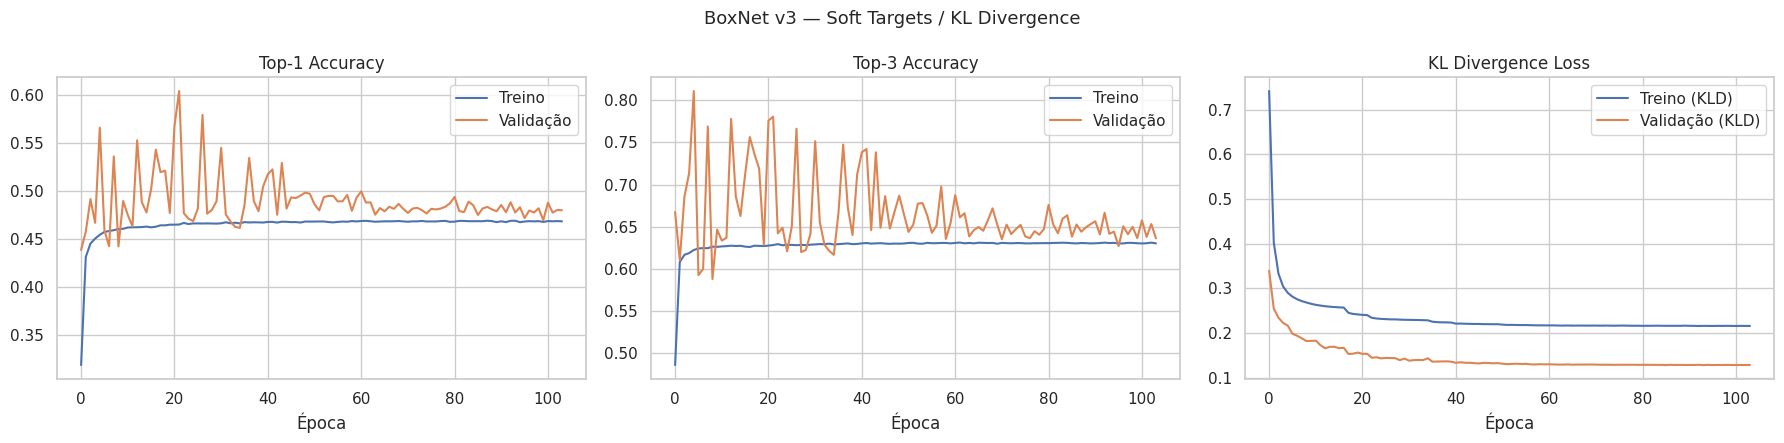


TOP-1 / TOP-3 ACCURACY POR FASE DO JOGO
  Fase                               N    Top-1    Top-3    Top-5
  Abertura (0-11 tracos)         41725   15.9%   26.2%   36.6%
  1ª Metade (12-17 tracos)       22759   51.0%   73.1%   83.3%
  2ª Metade (18-23 tracos)       22759   71.0%   89.8%   94.7%
  Fase Quente (24-28 tracos)     18966   69.6%   93.1%   97.7%
  Final (29-31 tracos)            7587   93.1%  100.0%  100.0%

  Optimal Move Accuracy (previsao in conjunto Minimax-otimo): 94.3%
  Media de jogadas Minimax-equivalentes por estado: 8.4


ANÁLISE DE VIÉS DE BORDAS (CNN vs MINIMAX)
  Global:
    Minimax joga na borda: 62.7%
    CNN joga na borda:     49.1%
    Viés (CNN - Minimax):  -13.6 pp

  Segmentado por Fase do Jogo:
    Abertura (0-11 tracos)     -> Minimax: 88.4% | CNN: 65.8% | Viés: -22.7 pp
    1ª Metade (12-17 tracos)   -> Minimax: 53.9% | CNN: 40.4% | Viés: -13.5 pp
    2ª Metade (18-23 tracos)   -> Minimax: 54.0% | CNN: 48.0% | Viés:  -6.0 pp
    Fase Quente (24-28 trac

In [26]:
# =========================================================================
# 4. AVALIAÇÃO TEXTUAL — métricas para copiar/colar e comparar entre versões
#
# Com soft targets, y_train/val/test são distribuições de probabilidade.
# - model.evaluate retorna KLD (não cross-entropy) — magnitudes diferentes.
#   O que importa é a tendência (descendo) e o gap treino/val.
# - CategoricalAccuracy e TopKCategoricalAccuracy fazem argmax(y_true)
#   internamente, então top-1/top-3/top-5 continuam interpretáveis como
#   "o modelo escolheu a melhor jogada do Minimax no top-K?".
# =========================================================================

def avalia_conjunto(nome, X, y_soft):
    m = model.evaluate(X, y_soft, verbose=0, return_dict=True)
    return {
        'conjunto': nome,
        'amostras': X.shape[0],
        'kld_loss':  m['loss'],
        'top1_acc':  m['accuracy'],
        'top3_acc':  m['top3_acc'],
        'top5_acc':  m['top5_acc'],
    }

resultados = pd.DataFrame([
    avalia_conjunto('Treino',    X_train, y_train),
    avalia_conjunto('Validação', X_val,   y_val),
    avalia_conjunto('Teste',     X_test,  y_test),
])
print("=" * 70)
print("RESUMO DE DESEMPENHO (BoxNet v3 — soft targets / KL Divergence)")
print("=" * 70)
print(resultados.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

gap_top1 = resultados.loc[0, 'top1_acc'] - resultados.loc[1, 'top1_acc']
gap_kld  = resultados.loc[1, 'kld_loss'] - resultados.loc[0, 'kld_loss']
print(f"\nGap top1 (Treino - Val): {gap_top1*100:+.2f} pp   [< 5 pp saudável; > 10 pp = overfit]")
print(f"Gap KLD  (Val - Treino): {gap_kld:+.4f}")

ult = len(history.history['loss']) - 1
print(f"\nÚltima época: {ult+1}")
print(f"  kld_loss  treino={history.history['loss'][ult]:.4f}  val={history.history['val_loss'][ult]:.4f}")
print(f"  top1_acc  treino={history.history['accuracy'][ult]:.4f}  val={history.history['val_accuracy'][ult]:.4f}")

# =========================================================================
# Classification report — usa argmax do soft target como rótulo verdadeiro
# (argmax do Q-value = melhor jogada do Minimax, mesma semântica de antes)
# =========================================================================
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_idx  = y_pred_prob.argmax(axis=1)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT (conjunto de TESTE)")
print("=" * 70)
report = classification_report(
    y_test_idx, y_pred_idx,
    labels=list(range(num_classes)),
    target_names=[indice_para_rotulo[i] for i in range(num_classes)],
    digits=4, zero_division=0, output_dict=True,
)
print(f"  accuracy:      {report['accuracy']:.4f}")
print(f"  macro avg:     P={report['macro avg']['precision']:.4f}  "
      f"R={report['macro avg']['recall']:.4f}  F1={report['macro avg']['f1-score']:.4f}")
print(f"  weighted avg:  P={report['weighted avg']['precision']:.4f}  "
      f"R={report['weighted avg']['recall']:.4f}  F1={report['weighted avg']['f1-score']:.4f}")

por_classe = pd.DataFrame({
    rotulo: report[rotulo]
    for rotulo in [indice_para_rotulo[i] for i in range(num_classes)]
}).T
por_classe.index.name = 'jogada'
por_classe = por_classe.sort_values('f1-score', ascending=False)

# Bordas do tabuleiro (9x7 matriz):
BORDAS = {
    'H_0_1', 'H_0_3', 'H_0_5', # Topo
    'H_8_1', 'H_8_3', 'H_8_5', # Base
    'V_1_0', 'V_3_0', 'V_5_0', 'V_7_0', # Esquerda
    'V_1_6', 'V_3_6', 'V_5_6', 'V_7_6'  # Direita
}

por_classe['borda'] = por_classe.index.isin(BORDAS)
por_classe['jogada_formatada'] = por_classe.index.map(lambda x: f"{x} (Borda)" if x in BORDAS else x)
por_classe_display = por_classe.set_index('jogada_formatada')

print("Top 10 jogadas com melhor F1 (onde o modelo brilha):")
print(por_classe_display.head(10)[['precision', 'recall', 'f1-score', 'support']]
      .to_string(float_format=lambda v: f"{v:.4f}"))
print("Bottom 5 jogadas (onde o modelo mais erra — verificar bordas):")
print(por_classe_display.tail(5)[['precision', 'recall', 'f1-score', 'support']]
      .to_string(float_format=lambda v: f"{v:.4f}"))
print("\nBottom 5 jogadas (onde o modelo mais erra — verificar bordas):")
print(por_classe.tail(5)[['precision', 'recall', 'f1-score', 'support']]
      .to_string(float_format=lambda v: f"{v:.4f}"))

# =========================================================================
# Gráficos de treino
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(history.history['accuracy'],     label='Treino')
axes[0].plot(history.history['val_accuracy'], label='Validação')
axes[0].set_title('Top-1 Accuracy')
axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['top3_acc'],     label='Treino')
axes[1].plot(history.history['val_top3_acc'], label='Validação')
axes[1].set_title('Top-3 Accuracy')
axes[1].set_xlabel('Época'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(history.history['loss'],     label='Treino (KLD)')
axes[2].plot(history.history['val_loss'], label='Validação (KLD)')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Época'); axes[2].legend(); axes[2].grid(True)

plt.suptitle('BoxNet v3 — Soft Targets / KL Divergence', fontsize=13)
plt.tight_layout(); plt.show()
# =========================================================================
# 5. METRICAS DIAGNOSTICAS EXTRAS
# =========================================================================

# 5.1  Top-1 / Top-3 por fase do jogo
# Reutiliza tracos_test já calculado globalmente na célula de dados
# (seção 1.3b). Evita recomputar a máscara e a contagem sobre X_test.
tracos_jogados = tracos_test

fases = [
    (0,  11, 'Abertura (0-11 tracos)'),
    (12, 17, '1ª Metade (12-17 tracos)'),
    (18, 23, '2ª Metade (18-23 tracos)'),
    (24, 28, 'Fase Quente (24-28 tracos)'),
    (29, 31, 'Final (29-31 tracos)'),
]
print('\n' + '=' * 70)
print('TOP-1 / TOP-3 ACCURACY POR FASE DO JOGO')
print('=' * 70)
print(f"  {'Fase':<28}  {'N':>6}  {'Top-1':>7}  {'Top-3':>7}  {'Top-5':>7}")
for lo, hi, nome in fases:
    mask = (tracos_jogados >= lo) & (tracos_jogados <= hi)
    if mask.sum() == 0:
        continue
    t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()
    top3_pred = np.argsort(y_pred_prob[mask], axis=1)[:, -3:]
    t3 = (top3_pred == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    top5_pred = np.argsort(y_pred_prob[mask], axis=1)[:, -5:]
    t5 = (top5_pred == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    print(f"  {nome:<28}  {mask.sum():>6}  {t1:>6.1%}  {t3:>6.1%}  {t5:>6.1%}")

# 5.2  Optimal Move Accuracy
# A previsao top-1 pertence ao conjunto de jogadas Minimax-otimas?
# S_test contem Q-values brutos; otimo = score == max_score (e slot disponivel)
max_scores_test = S_test.max(axis=1, keepdims=True)
eh_otimo       = (S_test == max_scores_test) & (S_test > -1e8)
pred_eh_otimo  = eh_otimo[np.arange(len(y_pred_idx)), y_pred_idx]
optimal_acc    = pred_eh_otimo.mean()
media_equiv    = eh_otimo.sum(axis=1).mean()
print(f'\n  Optimal Move Accuracy (previsao in conjunto Minimax-otimo): {optimal_acc:.1%}')
print(f'  Media de jogadas Minimax-equivalentes por estado: {media_equiv:.1f}')
print()

# =========================================================================
# 5.4  Análise de Jogadas nas Bordas (Viés do Modelo)
# Avalia se a CNN está enviesada a jogar nas bordas mais do que o Minimax
# =========================================================================
print('\n' + '=' * 70)
print('ANÁLISE DE VIÉS DE BORDAS (CNN vs MINIMAX)')
print('=' * 70)

# Converter previsões e alvos em labels (nomes reais dos traços)
# y_test_idx tem a verdade-padrão (Minimax), y_pred_idx tem a escolha Top-1 da CNN
labels_test = np.array([indice_para_rotulo[i] for i in y_test_idx])
labels_pred = np.array([indice_para_rotulo[i] for i in y_pred_idx])

# Identificar se a jogada foi na borda
borda_test = np.isin(labels_test, list(BORDAS))
borda_pred = np.isin(labels_pred, list(BORDAS))

print(f"  Global:")
print(f"    Minimax joga na borda: {borda_test.mean():.1%}")
print(f"    CNN joga na borda:     {borda_pred.mean():.1%}")
print(f"    Viés (CNN - Minimax):  {(borda_pred.mean() - borda_test.mean()) * 100:+.1f} pp")

print("\n  Segmentado por Fase do Jogo:")
for lo, hi, nome in fases:
    mask = (tracos_jogados >= lo) & (tracos_jogados <= hi)
    if mask.sum() == 0: continue

    b_test_fase = borda_test[mask].mean()
    b_pred_fase = borda_pred[mask].mean()
    vies = (b_pred_fase - b_test_fase) * 100

    print(f"    {nome:<26} -> Minimax: {b_test_fase:>5.1%} | CNN: {b_pred_fase:>5.1%} | Viés: {vies:>5.1f} pp")


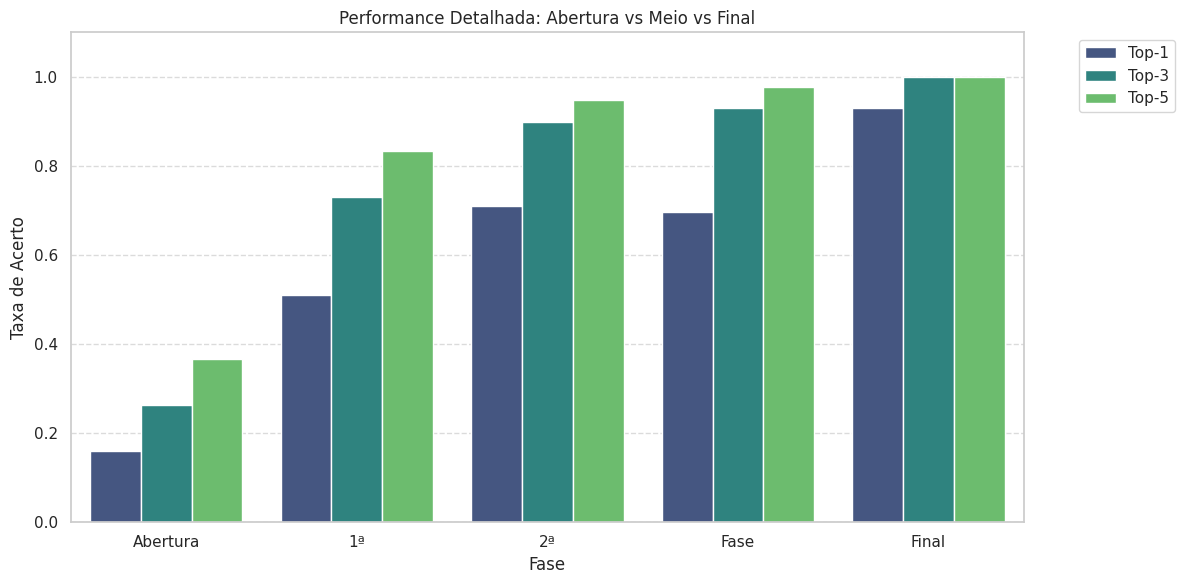

In [27]:
# =========================================================================
# 5.3 VISUALIZAÇÃO POR FASE (Gráfico Comparativo)
# =========================================================================
dados_fases = []
for lo, hi, nome in fases:
    mask = (tracos_jogados >= lo) & (tracos_jogados <= hi)
    if mask.sum() > 0:
        # Top-1
        t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()

        # Top-3 e Top-5
        argsorted_preds = np.argsort(y_pred_prob[mask], axis=1)
        top3_pred = argsorted_preds[:, -3:]
        top5_pred = argsorted_preds[:, -5:]

        t3 = (top3_pred == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
        t5 = (top5_pred == y_test_idx[mask, np.newaxis]).any(axis=1).mean()

        fase_nome = nome.split(' ')[0]
        dados_fases.append({'Fase': fase_nome, 'Métrica': 'Top-1', 'Acurácia': t1})
        dados_fases.append({'Fase': fase_nome, 'Métrica': 'Top-3', 'Acurácia': t3})
        dados_fases.append({'Fase': fase_nome, 'Métrica': 'Top-5', 'Acurácia': t5})

df_fases = pd.DataFrame(dados_fases)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_fases, x='Fase', y='Acurácia', hue='Métrica', palette='viridis')
plt.title('Performance Detalhada: Abertura vs Meio vs Final')
plt.ylim(0, 1.1)
plt.ylabel('Taxa de Acerto')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
# =========================================================================
# EXPORTACAO PARA TENSORFLOW LITE
# =========================================================================
import shutil

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

nome_arquivo = 'pontinhos_pequeno_profundidade_7_v7_base_adaptativa_com_duplicados.tflite'

# 1) Salva localmente na instância Colab
with open(nome_arquivo, 'wb') as f:
    f.write(tflite_model)
print(f'Modelo salvo localmente: {nome_arquivo} ({len(tflite_model)/1024:.1f} KB)')

# 2) Copia para o Google Drive — persiste mesmo que a instância caia
drive_path = os.path.join(DRIVE_OUTPUT_DIR, nome_arquivo)
shutil.copy(nome_arquivo, drive_path)
print(f'Modelo salvo no Drive:   {drive_path}')

# 3) Oferece download direto (só funciona se a sessão ainda estiver ativa)
try:
    from google.colab import files
    files.download(nome_arquivo)
except Exception:
    print('Download automatico nao disponivel — use o arquivo salvo no Drive.')

Saved artifact at '/tmp/tmpu8fhtjix'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9, 7, 1), dtype=tf.float32, name='tabuleiro_cru')
Output Type:
  TensorSpec(shape=(None, 31), dtype=tf.float32, name=None)
Captures:
  132418276840976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276842128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276841936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276841552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276842704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276841168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276843088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276843280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276843472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276841360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276843856:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# =========================================================================
# EXPORTACAO PARA TENSORFLOW LITE
# =========================================================================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

nome_arquivo = 'pontinhos_pequeno_profundidade_7_v7_base_adaptativa_com_duplicados.tflite'
with open(nome_arquivo, 'wb') as f:
    f.write(tflite_model)
print(f'Modelo salvo: {nome_arquivo} ({len(tflite_model)/1024:.1f} KB)')

from google.colab import files
files.download(nome_arquivo)


Saved artifact at '/tmp/tmpx58essaj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9, 7, 1), dtype=tf.float32, name='tabuleiro_cru')
Output Type:
  TensorSpec(shape=(None, 31), dtype=tf.float32, name=None)
Captures:
  132418276840976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276842128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276841936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276841552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276842704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276841168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276843088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276843280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276843472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276841360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132418276843856:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>